In [1]:
import pandas as pd
from pathlib import Path
from ifc.config import load_data_config
from ifc.config import resolve_project_root

**Imports and setup**
We load the core libraries and project utilities needed to read data and run the EDA.

In [2]:
data_cfg = load_data_config()

train_path, test_path = data_cfg.resolve_paths()

print(train_path)

C:\Users\morio\OneDrive\Desktop\Projects\italian-financial-challenge\data\processed\train_data.csv


**5) Eda Outlier mechanism diagnosis (ratio explosion check)**:
The target variable `revenue_change` is defined as a year-over-year percentage change:

revenue_change = ((production_value_t − production_value_{t−1}) / production_value_{t−1}) × 100

As a consequence, extreme target values may arise not only from large absolute changes
in revenue, but also from very small values of the denominator (prior-year revenue).



In [3]:
df = pd.read_csv(train_path)




We read the training dataset containing firm-year observations (company_id, fiscal_year).

In [4]:
df = df.sort_values(["company_id", "fiscal_year"]).copy()


We sort observations by company and fiscal year to ensure that lagged values
correctly correspond to the previous year within each firm.


In [5]:
df["production_value_lag1"] = (
    df.groupby("company_id")["production_value"]
      .shift(1)
)


This variable reconstructs the implicit denominator of the target formula,
namely the production value observed in the previous fiscal year (t−1).


**pv_lag1 (feature name) and lag-1 persistence** 
In the feature set, the lagged production value is referred to as pv_lag1.
In this notebook we reconstructed it as production_value_lag1 (production value at t−1).
We now measure whether lag-1 persistence is stable over time or breaks around 2020–2021 (COVID shock), which would indicate a regime change rather than random noise.

In [6]:
# Alias to match the assignment feature name
df["pv_lag1"] = df["production_value_lag1"]


pv_lag1 refers to production value at t−1 (same as production_value_lag1).

In [7]:
# Overall lag-1 correlation: how much pv(t) is explained by pv(t-1)
tmp = df.dropna(subset=["production_value", "pv_lag1"]).copy()
overall_corr = tmp["production_value"].corr(tmp["pv_lag1"])
overall_corr


np.float64(0.14685926835163676)

We compute Corr(pv(t), pv(t−1)). A low value indicates weak persistence (lag-1 information is limited).

In [8]:
# Lag-1 correlation by year (regime change check)
corr_by_year = (
    tmp.groupby("fiscal_year")
       .apply(lambda g: g["production_value"].corr(g["pv_lag1"]))
       .reset_index(name="lag1_correlation")
)

corr_by_year


C:\Users\morio\AppData\Local\Temp\ipykernel_22208\3542976370.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["production_value"].corr(g["pv_lag1"]))


,fiscal_year,lag1_correlation
0,2019,0.176208
1,2020,0.092157
2,2021,0.195070


We compute the same lag-1 correlation separately by year to detect structural breaks (e.g., COVID period).

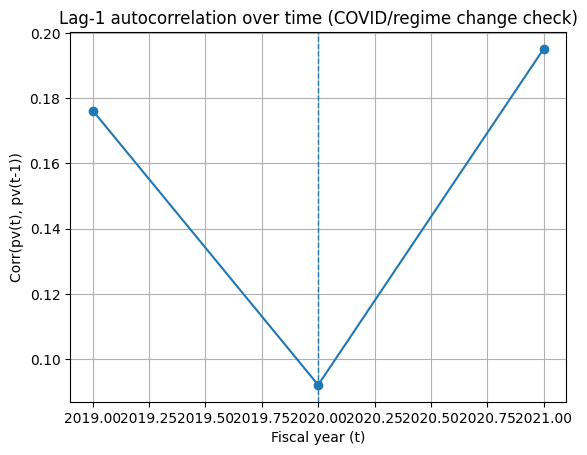

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(
    corr_by_year["fiscal_year"],
    corr_by_year["lag1_correlation"],
    marker="o"
)
plt.axvline(2020, linestyle="--", linewidth=1)

plt.xlabel("Fiscal year (t)")
plt.ylabel("Corr(pv(t), pv(t-1))")
plt.title("Lag-1 autocorrelation over time (COVID/regime change check)")
plt.grid(True)
plt.show()


If lag-1 correlation drops specifically around 2020–2021, the low persistence is likely structural (shock) rather than random noise.

In [10]:
# Year-level aggregates to visualize COVID shock and rebound
year_stats = (
    df.groupby("fiscal_year")
      .agg(
          n=("company_id", "size"),
          median_pv=("production_value", "median"),
          median_revchg=("revenue_change", "median"),
      )
      .reset_index()
)

year_stats


,fiscal_year,n,median_pv,median_revchg
0,2018,2961,7.923306e+08,NaN
1,2019,2979,7.959190e+08,1.820
2,2020,2956,7.821671e+08,0.340
3,2021,2932,8.552041e+08,7.495


We summarize median production value and median revenue change by year to highlight the 2020 drop and 2021 rebound.

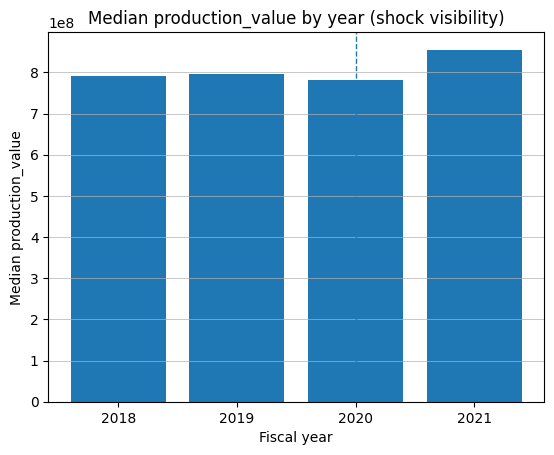

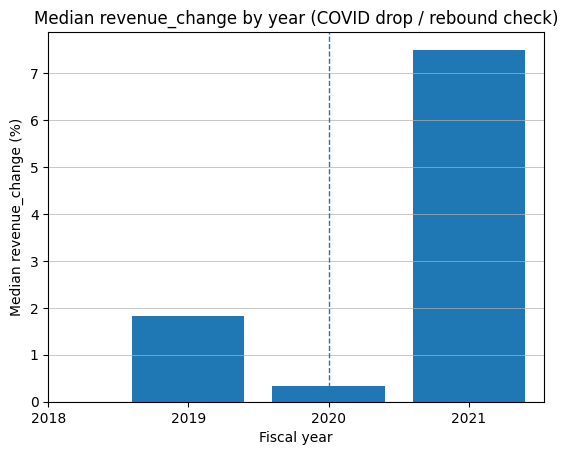

In [11]:
years = year_stats["fiscal_year"].astype(int).values

# --- Barplot: Median production_value by year (shock visibility) ---
plt.figure()
plt.bar(years, year_stats["median_pv"].values)
plt.axvline(2020, linestyle="--", linewidth=1)
plt.xlabel("Fiscal year")
plt.ylabel("Median production_value")
plt.title("Median production_value by year (shock visibility)")
plt.grid(True, axis="y", linewidth=0.5)
plt.xticks(years, years)  # <-- anni SOLO interi (niente 2018.5)
plt.show()

# --- Barplot: Median revenue_change by year (COVID drop / rebound check) ---
plt.figure()
plt.bar(years, year_stats["median_revchg"].values)
plt.axvline(2020, linestyle="--", linewidth=1)
plt.axhline(0, linewidth=0.8)
plt.xlabel("Fiscal year")
plt.ylabel("Median revenue_change (%)")
plt.title("Median revenue_change by year (COVID drop / rebound check)")
plt.grid(True, axis="y", linewidth=0.5)
plt.xticks(years, years)  # <-- anni SOLO interi (niente 2018.5)
plt.show()



These plots provide direct evidence of a shock (2020) and potential rebound (2021), supporting a regime-change interpretation.

In [12]:
den = df["production_value_lag1"]

share_nan = den.isna().mean()                 # primo anno osservato per azienda
p5 = den.dropna().quantile(0.05)              # soglia "near zero" = bottom 5%
share_below_p5 = (den < p5).mean()            # quota denominatori molto piccoli
share_leq_0 = (den <= 0).mean()               # controllo valori <= 0 (se presenti)

share_nan, p5, share_below_p5, share_leq_0


(np.float64(0.25355089617855936),
 np.float64(78369336.73200001),
 np.float64(0.03736895502198174),
 np.float64(0.0))


We quantify how often the denominator is problematic. A non-trivial share of observations has a very small
`production_value_lag1` (bottom 5%), which mechanically amplifies the target ratio and contributes to heavy-tailed outliers.



In [13]:
df["abs_revenue_change"] = df["revenue_change"].abs()


We use abs_revenue_change to identify extreme YoY changes regardless of sign.

In [14]:
top20 = (
    df.sort_values("abs_revenue_change", ascending=False)
      .loc[:, [
          "company_id",
          "fiscal_year",
          "production_value_lag1",
          "production_value",
          "revenue_change"
      ]]
      .head(20)
)

top20


,company_id,fiscal_year,production_value_lag1,production_value,revenue_change
9793,COMP_02485,2021,3.351168e+07,1.012812e+11,302126.48
380,COMP_00096,2020,4.856124e+06,1.034987e+10,213030.29
5876,COMP_01490,2021,9.048074e+06,1.232272e+10,136091.65
8571,COMP_02174,2019,2.363747e+07,1.752024e+10,74020.61
11557,COMP_02932,2019,3.080814e+07,1.893038e+10,61346.04
3543,COMP_00896,2021,1.363047e+08,7.208317e+10,52783.86
1765,COMP_00450,2020,7.906439e+07,2.926382e+10,36912.64
11471,COMP_02910,2020,7.870927e+08,2.762358e+11,34995.72
1840,COMP_00469,2019,4.681431e+08,1.570978e+11,33457.64
2959,COMP_00749,2020,3.897862e+07,1.275458e+10,32622.00


**Apparent motivations for small denominators**  
Very small values of `production_value_lag1` are consistent with firms operating at a very small economic scale
(micro-enterprises), firms in early stages of activity, or firms experiencing temporary contractions in the
previous year. In these cases, even moderate absolute changes in revenue can translate into extreme percentage
variations.


In [15]:
df["delta_production_value"] = df["production_value"] - df["production_value_lag1"]

top20_extended = (
    df.sort_values("abs_revenue_change", ascending=False)
      .loc[:, [
          "company_id",
          "fiscal_year",
          "production_value_lag1",
          "production_value",
          "delta_production_value",
          "revenue_change"
      ]]
      .head(20)
)

top20_extended


,company_id,fiscal_year,production_value_lag1,production_value,delta_production_value,revenue_change
9793,COMP_02485,2021,3.351168e+07,1.012812e+11,1.012476e+11,302126.48
380,COMP_00096,2020,4.856124e+06,1.034987e+10,1.034502e+10,213030.29
5876,COMP_01490,2021,9.048074e+06,1.232272e+10,1.231367e+10,136091.65
8571,COMP_02174,2019,2.363747e+07,1.752024e+10,1.749660e+10,74020.61
11557,COMP_02932,2019,3.080814e+07,1.893038e+10,1.889957e+10,61346.04
3543,COMP_00896,2021,1.363047e+08,7.208317e+10,7.194687e+10,52783.86
1765,COMP_00450,2020,7.906439e+07,2.926382e+10,2.918476e+10,36912.64
11471,COMP_02910,2020,7.870927e+08,2.762358e+11,2.754487e+11,34995.72
1840,COMP_00469,2019,4.681431e+08,1.570978e+11,1.566296e+11,33457.64
2959,COMP_00749,2020,3.897862e+07,1.275458e+10,1.271560e+10,32622.00


**Interpretation**
By comparing `delta_production_value` with `production_value_lag1`, we can see that extremely large percentage changes
often arise even when the absolute change is not extreme, because the prior-year denominator is very small (ratio explosion).


In [16]:
# Define near-zero denominator as bottom 5%
p5 = df["production_value_lag1"].dropna().quantile(0.05)

# Define extreme targets as top 1% of |revenue_change|
thr = df["abs_revenue_change"].quantile(0.99)

extreme = df["abs_revenue_change"] >= thr
near_zero = df["production_value_lag1"] < p5

share_near_zero = (extreme & near_zero).sum() / extreme.sum()

p5, thr, share_near_zero


(np.float64(78369336.73200001),
 np.float64(6313.31359999999),
 np.float64(0.33707865168539325))

We quantify the mechanism by measuring the share of extreme target observations
(top 1% in absolute value) whose prior-year production value lies in the bottom 5%
of the distribution.


In [17]:
# share_near_zero by year: is it time-concentrated or random?
tmp2 = df.dropna(subset=["production_value_lag1", "abs_revenue_change"]).copy()

# Use global thresholds (stable comparison across years)
p5_global = tmp2["production_value_lag1"].quantile(0.05)
thr_global = tmp2["abs_revenue_change"].quantile(0.99)

tmp2["near_zero"] = tmp2["production_value_lag1"] < p5_global
tmp2["extreme"] = tmp2["abs_revenue_change"] >= thr_global

share_by_year = (
    tmp2.groupby("fiscal_year")
        .apply(lambda g: (g["near_zero"] & g["extreme"]).sum() / max(g["extreme"].sum(), 1))
        .reset_index(name="share_near_zero_among_extremes")
)

share_by_year


C:\Users\morio\AppData\Local\Temp\ipykernel_22208\474579928.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g["near_zero"] & g["extreme"]).sum() / max(g["extreme"].sum(), 1))


,fiscal_year,share_near_zero_among_extremes
0,2019,0.323529
1,2020,0.294118
2,2021,0.428571


We compute share_near_zero by year to test whether near-zero denominators cluster during shock periods.

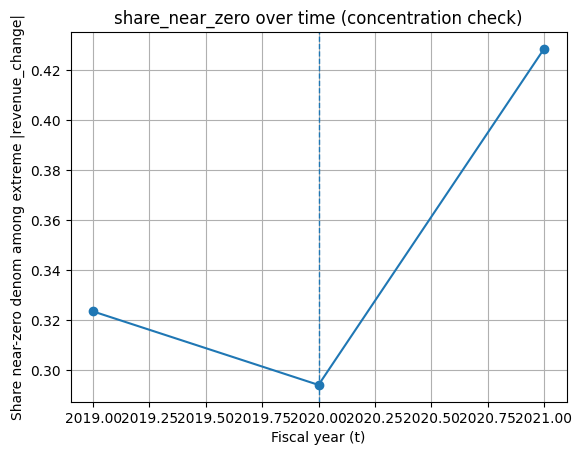

In [18]:
plt.figure()
plt.plot(
    share_by_year["fiscal_year"],
    share_by_year["share_near_zero_among_extremes"],
    marker="o"
)
plt.axvline(2020, linestyle="--", linewidth=1)
plt.xlabel("Fiscal year (t)")
plt.ylabel("Share near-zero denom among extreme |revenue_change|")
plt.title("share_near_zero over time (concentration check)")
plt.grid(True)
plt.show()


Peaks around 2020–2021 indicate share_near_zero is not random in time, but concentrated in crisis years.

In [19]:
# Overall near-zero rate by year (not restricted to extreme targets)
near_zero_rate_by_year = (
    tmp2.groupby("fiscal_year")["near_zero"]
        .mean()
        .reset_index(name="near_zero_rate")
)

near_zero_rate_by_year


,fiscal_year,near_zero_rate
0,2019,0.053383
1,2020,0.050068
2,2021,0.046726


This measures how often pv_lag1 is near-zero each year, not only among extreme target values.

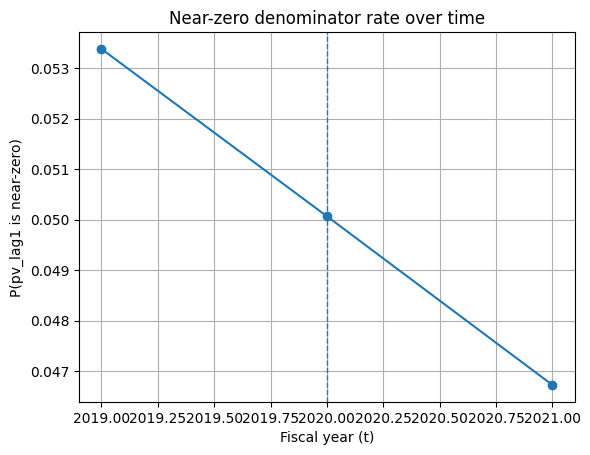

In [20]:
plt.figure()
plt.plot(near_zero_rate_by_year["fiscal_year"], near_zero_rate_by_year["near_zero_rate"], marker="o")
plt.axvline(2020, linestyle="--", linewidth=1)
plt.xlabel("Fiscal year (t)")
plt.ylabel("P(pv_lag1 is near-zero)")
plt.title("Near-zero denominator rate over time")
plt.grid(True)
plt.show()


**Are the dynamics structural or random?**
If lag-1 correlation drops specifically around 2020–2021 and share_near_zero peaks in the same period, the observed behavior is consistent with a structural regime change (COVID shock + rebound) rather than pure random noise.

**Modeling implications**

Lag features may lose predictive power during regime shifts (non-stationarity).

Near-zero denominators should be treated as informative stress signals (indicator features + stable transforms like log1p).

Prefer robust modeling choices (robust target transformations such as signed-log/asinh, and models capturing non-linearities and heterogeneity, e.g., tree-based methods) and consider time controls (year effects / interactions).

**Takeaway (EDA 5)**:
Extreme values of `revenue_change` are largely consistent with denominator effects:
when prior-year production value is very small, the ratio defining the target
can explode even for moderate absolute changes. This explains the presence of
heavy-tailed outliers and motivates the use of robust modeling strategies
(e.g., winsorization or target transformations). These findings directly inform feature engineering and robust target handling choices in the forecasting model.



In [21]:
import numpy as np

df["is_small_denom_p5"] = (df["production_value_lag1"] < p5).astype(int)
df["log_production_value_lag1"] = np.log1p(df["production_value_lag1"].clip(lower=0))

df[["is_small_denom_p5", "log_production_value_lag1"]].head()


,is_small_denom_p5,log_production_value_lag1
0,0,NaN
1,0,21.336631
2,0,19.876771
3,0,22.662899
4,0,NaN


Practical strategies 
Since extreme targets are structurally linked to very small denominators, robust handling is justified:
- Target-side robustness: winsorization (e.g., clip extreme `revenue_change`), or robust transforms such as `sign(y)·log1p(|y|)`.
- Model-side robustness: use robust losses/metrics (MAE/Huber) to reduce sensitivity to outliers.
- Feature-side signals: include `production_value_lag1` (and `log_production_value_lag1`) plus an indicator `is_small_denom_p5`
  to explicitly inform the model when the ratio is unstable.


**6) ATECO segmentation (The "K-Shape" Check)**
After identifying strong temporal shocks in the target distribution,
we investigate whether these shocks affected economic sectors asymmetrically.


In [22]:
sector_summary = (
    df.groupby("ateco_sector")
      .agg(
          count=("revenue_change", "size"),
          median_revenue_change=("revenue_change", "median"),
          p95_revenue_change=("revenue_change", lambda s: s.quantile(0.95)),
      )
      .sort_values("count", ascending=False)
      .head(10)
)

sector_summary


,count,median_revenue_change,p95_revenue_change
ateco_sector,,,
46,1688,-6.87,1860.3130
47,1491,6.64,1575.0750
41,1465,8.41,2041.5165
43,1189,10.17,1467.3020
25,1095,4.93,1775.8380
10,958,-3.04,1635.1770
62,950,14.68,1870.4100
56,754,-2.72,1686.3490
45,662,1.32,1745.5250


This table summarizes target behavior across the most represented ATECO sectors.


In [23]:
# Median revenue change by sector and year
sector_year_pivot = (
    df.pivot_table(
        index="ateco_sector",
        columns="fiscal_year",
        values="revenue_change",
        aggfunc="median"
    )
    .round(2)
    .sort_values(by=2020)  # ordiniamo per shock 2020 (più leggibile)
)

sector_year_pivot



fiscal_year,2019,2020,2021
ateco_sector,,,
56,-8.38,-32.53,34.89
68,12.94,-25.67,36.02
10,2.78,-22.82,21.71
41,6.58,-8.89,26.29
43,6.37,-8.57,34.03
71,8.03,-3.14,1.09
25,19.04,1.12,-8.70
62,33.20,7.34,2.70
46,-15.80,9.98,-8.58


**How to read this table**  
- Each row represents an ATECO sector.
- Columns report the median year-over-year revenue change.
- The 2020 column captures the COVID shock.
- More negative values in 2020 indicate sectors more severely affected by the pandemic.
- The 2021 column reflects recovery dynamics (rebound).


In [24]:
# Explicit shock and rebound metrics
sector_shock_rebound = sector_year_pivot.copy()

sector_shock_rebound["shock_2020_vs_2019"] = (
    sector_year_pivot[2020] - sector_year_pivot[2019]
)

sector_shock_rebound["rebound_2021_vs_2020"] = (
    sector_year_pivot[2021] - sector_year_pivot[2020]
)

sector_shock_rebound[["shock_2020_vs_2019", "rebound_2021_vs_2020"]].round(2)


fiscal_year,shock_2020_vs_2019,rebound_2021_vs_2020
ateco_sector,,
56,-24.15,67.42
68,-38.61,61.69
10,-25.60,44.53
41,-15.47,35.18
43,-14.94,42.60
71,-11.17,4.23
25,-17.92,-9.82
62,-25.86,-4.64
46,25.78,-18.56


**Interpretation (K-shaped pattern)**  
This transformation makes the COVID shock and subsequent rebound explicit.
Sectors differ substantially both in the magnitude of the 2020 contraction
and in the strength of the 2021 recovery, supporting a K-shaped recovery pattern
rather than a uniform economic response.


**Why this matters**  
Sector-level heterogeneity provides actionable signals:
- for forecasting models, `ateco_sector` is a key predictor during systemic shocks;
- for business decisions, sectors with larger historical shocks may require more conservative
  revenue projections and stronger risk buffers.


Median revenue changes are reported by sector and fiscal year to highlight
heterogeneous shock and recovery patterns.


In [25]:
sector_year = df.pivot_table(
    index="ateco_sector",
    columns="fiscal_year",
    values="revenue_change",
    aggfunc="median"
)

# crea colonne shock/rebound solo se gli anni esistono nel dataset
sector_metrics = sector_year.copy()

if 2019 in sector_metrics.columns and 2020 in sector_metrics.columns:
    sector_metrics["shock_2020_vs_2019"] = sector_metrics[2020] - sector_metrics[2019]

if 2020 in sector_metrics.columns and 2021 in sector_metrics.columns:
    sector_metrics["rebound_2021_vs_2020"] = sector_metrics[2021] - sector_metrics[2020]

# Mostra i settori con shock più negativo (crollo maggiore)
sector_metrics.sort_values("shock_2020_vs_2019", ascending=True).head(15)


fiscal_year,2019,2020,2021,shock_2020_vs_2019,rebound_2021_vs_2020
ateco_sector,,,,,
68,12.945,-25.670,36.020,-38.615,61.690
62,33.200,7.335,2.705,-25.865,-4.630
10,2.785,-22.820,21.710,-25.605,44.530
56,-8.385,-32.530,34.890,-24.145,67.420
25,19.040,1.125,-8.700,-17.915,-9.825
41,6.580,-8.890,26.290,-15.470,35.180
43,6.370,-8.570,34.025,-14.940,42.595
71,8.030,-3.140,1.090,-11.170,4.230
77,3.000,10.280,-15.050,7.280,-25.330


**K-shape quantification**:
We explicitly quantify sector-level asymmetry by measuring the 2020 shock (median 2020 minus median 2019)
and the rebound (median 2021 minus median 2020). Large negative shocks with positive rebounds are consistent
with a K-shaped pattern.


**Interpretation (business intuition)**:From the sector-year median pivot and the shock/rebound metrics, we observe substantial heterogeneity across sectors.
Sector heterogeneity is consistent with different exposure to COVID restrictions and demand shifts.
Activities requiring physical presence or discretionary spending tend to show sharper contractions in 2020,
while essential/digital-oriented sectors are more resilient and may recover faster.This supports using `ateco_sector` as a key predictor and suggests sector-level scenario planning:
sectors with historically larger shocks may require more conservative forecasts and stronger liquidity
or risk buffers during systemic events.




In [26]:
# Map ATECO 2-digit codes to macro categories (from data_dictionary.md)

def map_ateco_category(code):
    code = int(code)
    if 1 <= code <= 3:
        return "Agriculture"
    elif 5 <= code <= 9:
        return "Mining"
    elif 10 <= code <= 33:
        return "Manufacturing"
    elif code == 35:
        return "Energy"
    elif 36 <= code <= 39:
        return "Water & Waste"
    elif 41 <= code <= 43:
        return "Construction"
    elif 45 <= code <= 47:
        return "Trade"
    elif 49 <= code <= 53:
        return "Transport"
    elif 55 <= code <= 56:
        return "Accommodation & Food"
    elif 58 <= code <= 63:
        return "Information & Communication"
    elif 64 <= code <= 66:
        return "Finance & Insurance"
    elif code == 68:
        return "Real Estate"
    elif 69 <= code <= 75:
        return "Professional Services"
    elif 77 <= code <= 82:
        return "Administrative Services"
    elif code == 84:
        return "Public Administration"
    elif code == 85:
        return "Education"
    elif 86 <= code <= 88:
        return "Health & Social Work"
    elif 90 <= code <= 93:
        return "Arts & Entertainment"
    elif 94 <= code <= 96:
        return "Other Services"
    else:
        return "Other"

df["ateco_macro"] = df["ateco_sector"].astype(int).apply(map_ateco_category)


We group sectors into macro categories to analyze heterogeneous trajectories (K-shaped recovery).

In [27]:
# Median revenue_change by macro-sector and year
macro_year = (
    df.groupby(["ateco_macro", "fiscal_year"])["revenue_change"]
      .median()
      .reset_index()
)
macro_year


,ateco_macro,fiscal_year,revenue_change
0,Accommodation & Food,2018,NaN
1,Accommodation & Food,2019,-8.385
2,Accommodation & Food,2020,-32.530
3,Accommodation & Food,2021,34.890
4,Administrative Services,2018,NaN
5,Administrative Services,2019,-4.040
6,Administrative Services,2020,23.465
7,Administrative Services,2021,-18.710
8,Construction,2018,NaN
9,Construction,2019,6.475


This table is the input for the K-shaped recovery plot (median revenue change by macro-sector over time).

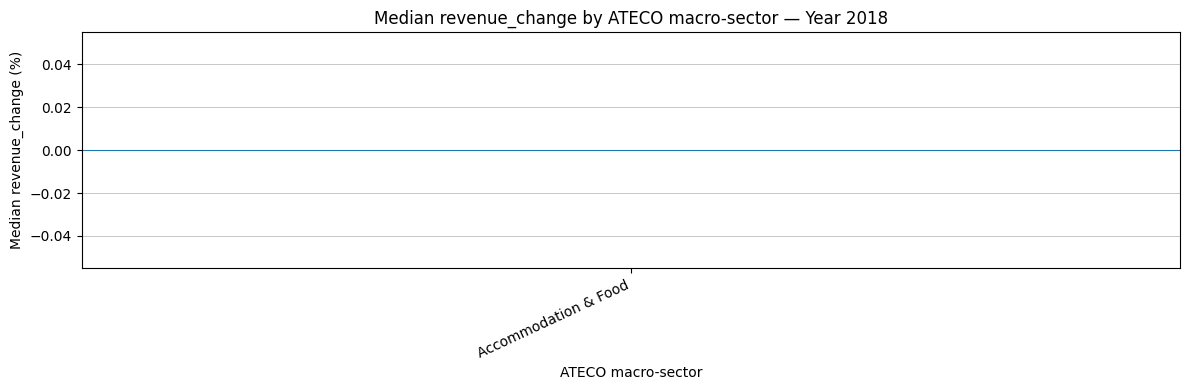

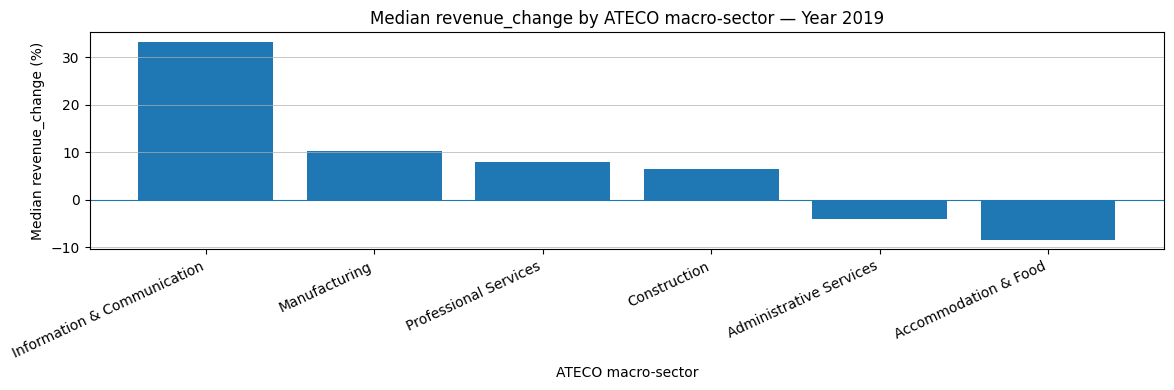

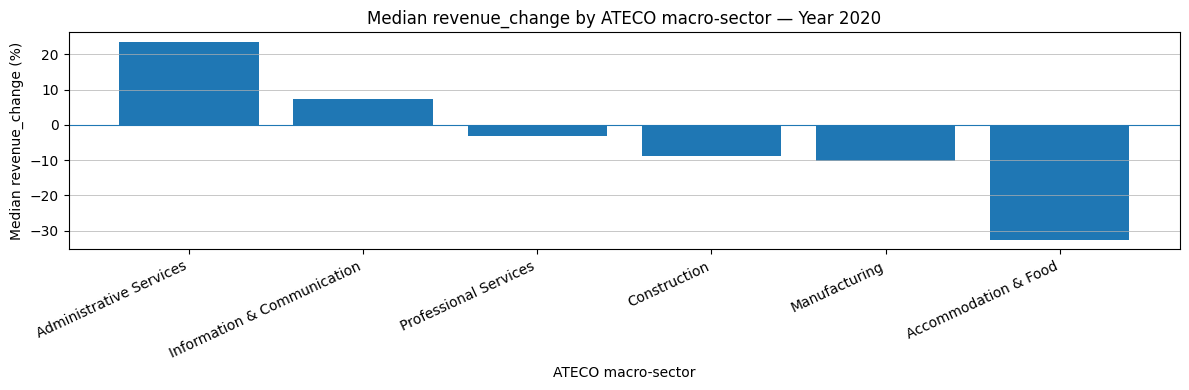

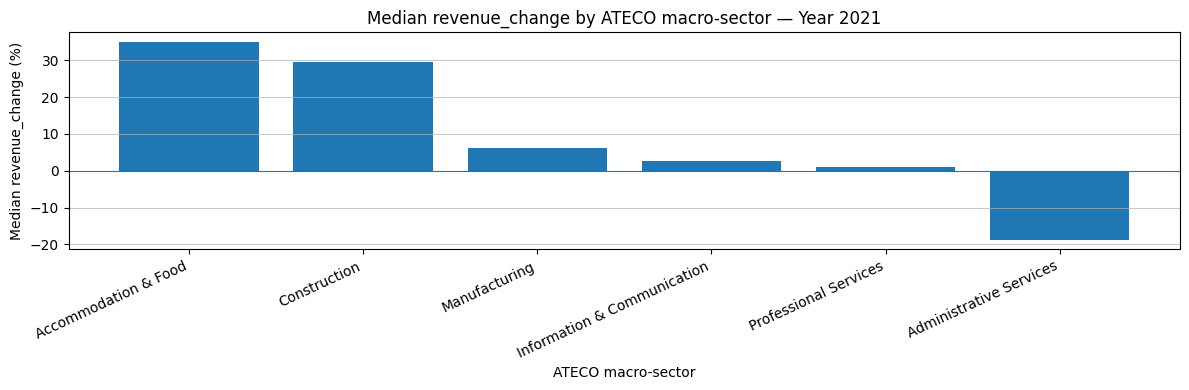

In [28]:
import matplotlib.pyplot as plt


top_macros = macro_year["ateco_macro"].value_counts().head(6).index
dfp = macro_year[macro_year["ateco_macro"].isin(top_macros)].copy()


dfp = dfp.dropna(subset=["fiscal_year"]).copy()
dfp["fy_int"] = dfp["fiscal_year"].round().astype(int)

#  Lista anni (tipicamente 2019, 2020, 2021) SOLO interi
years = sorted(dfp["fy_int"].unique())

#  Tre barplot: uno per anno, colonne = settori, ordinati decrescenti
for y in years:
    tmp = dfp[dfp["fy_int"] == y].copy()

    # una riga per settore: se per qualche motivo ci sono duplicati, prendi la mediana
    tmp = (tmp.groupby("ateco_macro", as_index=False)["revenue_change"]
              .median()
              .sort_values("revenue_change", ascending=False))

    plt.figure(figsize=(12, 4))
    plt.bar(tmp["ateco_macro"], tmp["revenue_change"])
    plt.axhline(0, linewidth=0.8)

    plt.title(f"Median revenue_change by ATECO macro-sector — Year {y}")
    plt.xlabel("ATECO macro-sector")
    plt.ylabel("Median revenue_change (%)")

    plt.xticks(rotation=25, ha="right")
    plt.grid(True, axis="y", linewidth=0.5)
    plt.tight_layout()
    plt.show()



**K-shaped recovery across ATECO macro-sectors**  
The figure shows median revenue changes over time for broad ATECO macro-categories.
The vertical line marks the COVID shock in 2020.  
Some sectors experience a sharp contraction followed by a strong rebound, while others remain relatively stable
or recover more slowly, clearly illustrating a K-shaped recovery rather than a uniform response.


**Why this matters**  
The heterogeneous trajectories across macro-sectors provide strong signals for both forecasting and business decisions.
Including sector information helps the model capture asymmetric shocks, while firms operating in historically fragile
sectors may require more conservative planning during systemic crises.


**Takeaway (EDA 6)**
Target volatility differs substantially across ATECO sectors, and the impact
of the 2020 shock is clearly asymmetric. Some sectors experience sharp contractions
followed by recovery, while others remain relatively stable, confirming the
presence of a K-shaped dynamic. This supports sector identity as a key predictor
for modeling revenue changes during the COVID period.
